# Phase 3.3 — MWPM decoding with PyMatching

Minimum-weight perfect matching (MWPM) is the baseline surface-code decoder. Given
the graphlike detector error model, PyMatching (Sparse Blossom) finds the
lowest-weight set of error edges consistent with the observed detectors and predicts
the logical-observable flips.

The pipeline is **Stim circuit → DEM → `pymatching.Matching` → `decode_batch` →
logical error rate**, wrapped by the promoted helpers
:func:`qec_project.decoders.pymatching_decoder.matching_from_dem` /
:func:`~qec_project.decoders.pymatching_decoder.decode_shots` and the Monte-Carlo
driver :func:`qec_project.decoders.harness.sample_cell`.

References (`docs/reading-list.md`): Higgott & Gidney, *Sparse Blossom*
(arXiv:2303.15933).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qec_project.codes.surface import RotatedSurfaceCode
from qec_project.decoders.pymatching_decoder import decode_shots, matching_from_dem
from qec_project.noise.circuit import depolarizing

code = RotatedSurfaceCode.memory(5)
noise = depolarizing(0.005)
circuit = code.circuit(noise)
dem = code.detector_error_model(noise)
matching = matching_from_dem(dem)
print("Matching built from DEM:", matching)

Matching built from DEM: <pymatching.Matching object with 120 detectors, 0 boundary nodes, and 502 edges>


## One batch, end to end

Sample detection events + the true observable flips from the circuit, decode, and
compare. The logical error rate is the fraction of shots where the prediction
disagrees with the truth.

In [2]:
rng_seed = 42
det, obs = circuit.compile_detector_sampler(seed=rng_seed).sample(
    50_000, separate_observables=True)
pred = decode_shots(matching, det)
errors = int(np.count_nonzero(np.any(pred != obs, axis=1)))
print(f"shots = {det.shape[0]:,}, logical errors = {errors}, "
      f"p_L (per shot) = {errors / det.shape[0]:.4f}")

# A 'do nothing' decoder (predict no flip) is the baseline MWPM must beat:
trivial = int(np.count_nonzero(np.any(obs != 0, axis=1)))
print(f"trivial decoder errors = {trivial}  ->  MWPM is {trivial / max(errors,1):.1f}x better")

shots = 50,000, logical errors = 691, p_L (per shot) = 0.0138
trivial decoder errors = 11583  ->  MWPM is 16.8x better


## A mini threshold sweep

`sample_cell` wraps the whole loop (seeded, with early-stop). Sweeping a few
physical error rates at $d = 3, 5$ already shows the surface-code signature:
**below threshold, increasing $d$ lowers the logical error rate.** The full
$d \in \{3,5,7\}$ production sweep lives in `capstone/experiments/` (Phase 3.4).

d=3: p=0.003:0.0073  p=0.005:0.0175  p=0.007:0.0319  p=0.01:0.0609


d=5: p=0.003:0.0034  p=0.005:0.0147  p=0.007:0.0352  p=0.01:0.0809


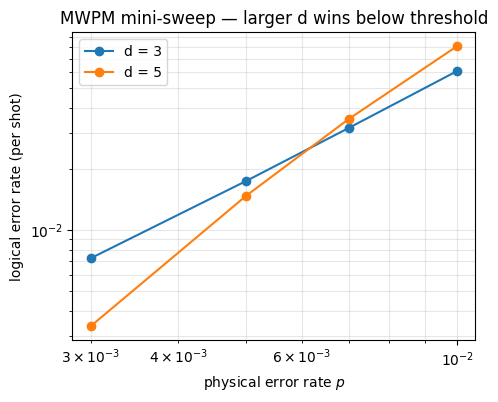

In [3]:
from qec_project.decoders.harness import sample_cell

ps = [0.003, 0.005, 0.007, 0.01]
plt.figure(figsize=(5.2, 4))
for d in (3, 5):
    ys = [sample_cell(decoder="pymatching", distance=d, p_phys=p, shots=20_000, seed=42).shot_error_rate
          for p in ps]
    plt.plot(ps, ys, "o-", label=f"d = {d}")
    print(f"d={d}: " + "  ".join(f"p={p}:{y:.4f}" for p, y in zip(ps, ys, strict=False)))
plt.xscale("log")
plt.yscale("log")
plt.xlabel("physical error rate $p$")
plt.ylabel("logical error rate (per shot)")
plt.title("MWPM mini-sweep — larger d wins below threshold")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## Recap

* PyMatching turns a Stim DEM into an MWPM decoder in one call; `decode_batch`
  decodes millions of shots per second.
* MWPM beats the trivial decoder by a wide margin below threshold.
* The $d=3$ vs $d=5$ curves already separate sub-threshold — the full crossing and
  threshold estimate are produced in Phase 3.4 / the capstone sweep.